# FastICA: Signal separation and denoising/compression

In [1]:
import numpy as np
import os
import pandas as pd
from datetime import datetime
import scipy.signal
import matplotlib.pyplot as plt
import matplotlib.ticker as plticker
from sklearn.decomposition import FastICA, PCA
from sklearn import preprocessing
from scipy import signal
from sklearn.preprocessing import StandardScaler
from datetime import datetime

In [101]:
# Using MPU only 
n = input('Which MPU dataset would you like to look at?')
df = pd.read_csv('/Users/konstantinmack/Documents/Studium/ETH/2. Semester/Master Project SMM (Konstruktiv)/04_Data Collection/170522/CSV/Vibration_MPUA_{}.csv'.format(n))
#df = pd.read_csv('CSV/Vibration_MPUA_{}.csv'.format(n))
#Using timestamp as index
df = df.drop(columns=['Timestamp (float)', 'Unnamed: 0']).set_index('Date and Timestamp (string)')
print(np.shape(df))
#plt.figure(figsize=(18, 3))
#plt.plot(df)

Which MPU dataset would you like to look at?14
(2346, 3)


In [104]:
# USING MPU and ADXL DATA (preprocessed)
n = input('Which MPU/ADXL dataset would you like to look at?')
dfa = pd.read_csv('/Users/konstantinmack/Documents/Studium/ETH/2. Semester/Master Project SMM (Konstruktiv)/04_Data Collection/170522/CSV/Vibration_MPUA_{}.csv'.format(n))
dfg = pd.read_csv('/Users/konstantinmack/Documents/Studium/ETH/2. Semester/Master Project SMM (Konstruktiv)/04_Data Collection/170522/CSV/Vibration_ADXL_{}.csv'.format(n))
#Fusing MPU files together (gyro and acc)
x=len(dfa)
y=len(dfg)
print(x,y)
if y > x:
    dfg.drop(dfg.tail(abs(x-y)).index,inplace=True) # drop last n rows
if x > y:
    dfa.drop(dfa.tail(abs(x-y)).index,inplace=True) # drop last n rows
x=len(dfa)
y=len(dfg)
print(x,y)
dfa['X-Acc ADXL [g]']=dfg['X-Acc ADXL [g]']
dfa['Y-Acc ADXL [g]']=dfg['Y-Acc ADXL [g]']
dfa['Z-Acc ADXL [g]']=dfg['Z-Acc ADXL [g]']
df=dfa

#Using timestamp as index
df = df.drop(columns=['Date and Timestamp (string)','Unnamed: 0']).set_index('Timestamp (float)')
df

Which MPU/ADXL dataset would you like to look at?14
2346 2346
2346 2346


,X-Acc MPU [g],Y-Acc MPU [g],Z-Acc MPU [g],X-Acc ADXL [g],Y-Acc ADXL [g],Z-Acc ADXL [g]
Timestamp (float),,,,,,
1.652779e+09,-0.048987,-0.046440,0.017800,-0.001708,-0.000223,0.015044
1.652779e+09,-0.213045,-0.126791,0.066024,-0.008845,-0.001353,0.066006
1.652779e+09,-0.369663,-0.078906,0.091169,-0.027250,-0.004351,0.117116
1.652779e+09,-0.332649,0.018284,0.062145,-0.062396,-0.009176,0.110802
1.652779e+09,-0.220324,-0.058749,0.047197,-0.115583,-0.013530,0.084502
...,...,...,...,...,...,...
1.652779e+09,-0.077323,0.203080,0.061760,-0.068189,0.204863,0.076919
1.652779e+09,-0.074515,0.215781,0.055521,-0.074152,0.197029,0.074396
1.652779e+09,-0.066306,0.228604,0.045742,-0.077910,0.194706,0.067228


### Centering and scaling the Data (Mean=0, Variance=1)

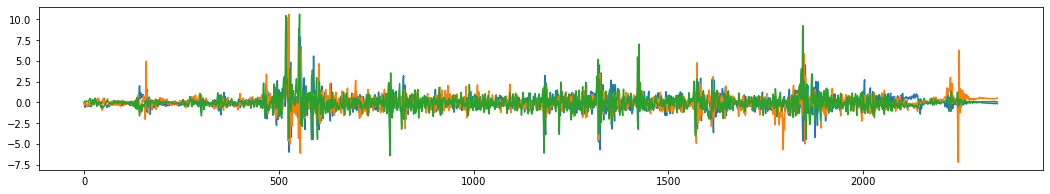

In [89]:
scaled_df = preprocessing.scale(df)
plt.figure(figsize=(18, 3))
plt.plot(scaled_df)

### Performing ICA

In [105]:
# Compute ICA
n_components = 3
ica = FastICA(n_components,max_iter=10000000,tol=0.00001) # define ICA
Y = ica.fit_transform(scaled_df)  # Fit and recover sources
W = ica.mixing_  # Get estimated mixing matrix, already pseudo inverse

print(W, np.shape(W))
print(Y, np.shape(Y))

[[ 29.44224576   0.42538899  38.45742073]
 [-41.53169448  -2.75253134  24.76977846]
 [  7.16499841 -47.39647681   6.94527058]] (3, 3)
[[ 0.0009475  -0.00098449 -0.00272631]
 [ 0.00132049 -0.00392299 -0.00971473]
 [-0.00298368 -0.00605721 -0.0128259 ]
 ...
 [-0.00947475 -0.00263431  0.00455997]
 [-0.00994972 -0.00215601  0.00446005]
 [-0.0103288  -0.00211676  0.00392015]] (2346, 3)


<Figure size 1296x216 with 0 Axes>

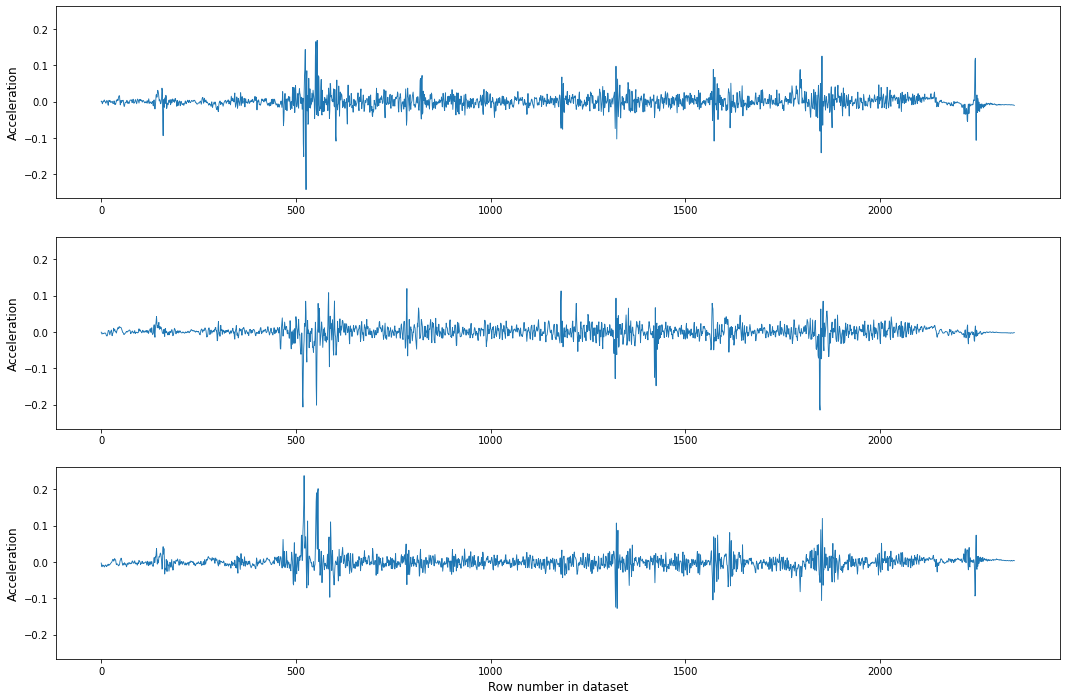

In [107]:
plt.figure(figsize=(18, 3))
fig, axs = plt.subplots(3, 1, figsize=(18, 12), sharey=True)
#ax1 = axs[0]
#ax1.plot(df)
ax2 = axs[0]
ax2.set_ylabel('Acceleration', fontsize=12)
ax2.plot(Y[:,0],linewidth=0.9)
ax3 = axs[1]
ax3.set_ylabel('Acceleration', fontsize=12)
ax3.plot(Y[:,1],linewidth=0.9)
ax4 = axs[2]
ax4.set_ylabel('Acceleration', fontsize=12)
ax4.plot(Y[:,2],linewidth=0.9)
ax4.set_xlabel('Row number in dataset', fontsize=12)
plt.show()

## Reconstructing the data

In [92]:
#check mixing matrix
print(np.shape(W),',',np.shape(Y))
print(W)

(3, 3) , (2346, 3)
[[  0.1483971  -30.72767425 -37.44045958]
 [ -2.0526108   40.70649081 -26.1680797 ]
 [-47.46795585  -6.71355748  -6.90806149]]


[[ 29.44224576   0.           0.        ]
 [-41.53169448   0.           0.        ]
 [  7.16499841   0.           0.        ]]


Text(0.5, 0, 'Row number in Dataset')

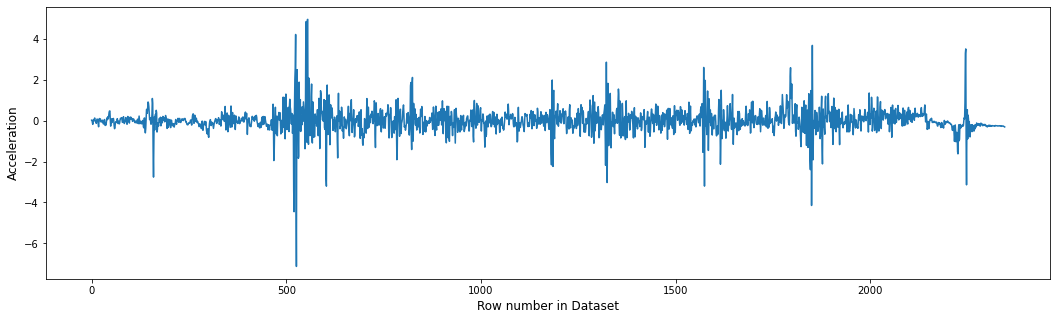

In [112]:
#Decide which of the separated sources contains the most information!
#Set the other 'noise columns' of mixing matrix W to zero (uncomment the one that is to be kept)
W_cl=W
#W_cl[:,0]=0
W_cl[:,1]=0
W_cl[:,2]=0
print(W)

#Perform Matrix multiplication for reconstruction
df_denoised = np.dot(W_cl,Y.T)
np.shape(df_denoised)

#Plot reconstructed signal
#When reconstructing using one column only, all three recreated components are the same according to amount
#Therefore, only one column needs to be plotted
plt.figure(figsize=(18, 5))
plt.plot(df_denoised.T[:,0])
plt.ylabel('Acceleration', fontsize=12)
plt.xlabel('Row number in Dataset', fontsize=12)